In [2]:
# Upload dataset and read it into a pandas DataFrame
%pip install pandas
import pandas as pd

path = r"C:\Users\ramir\OneDrive\TMU Capstone\HR-Employee-Attrition-Dataset.csv"
df = pd.read_csv(path)
df.head()

Note: you may need to restart the kernel to use updated packages.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


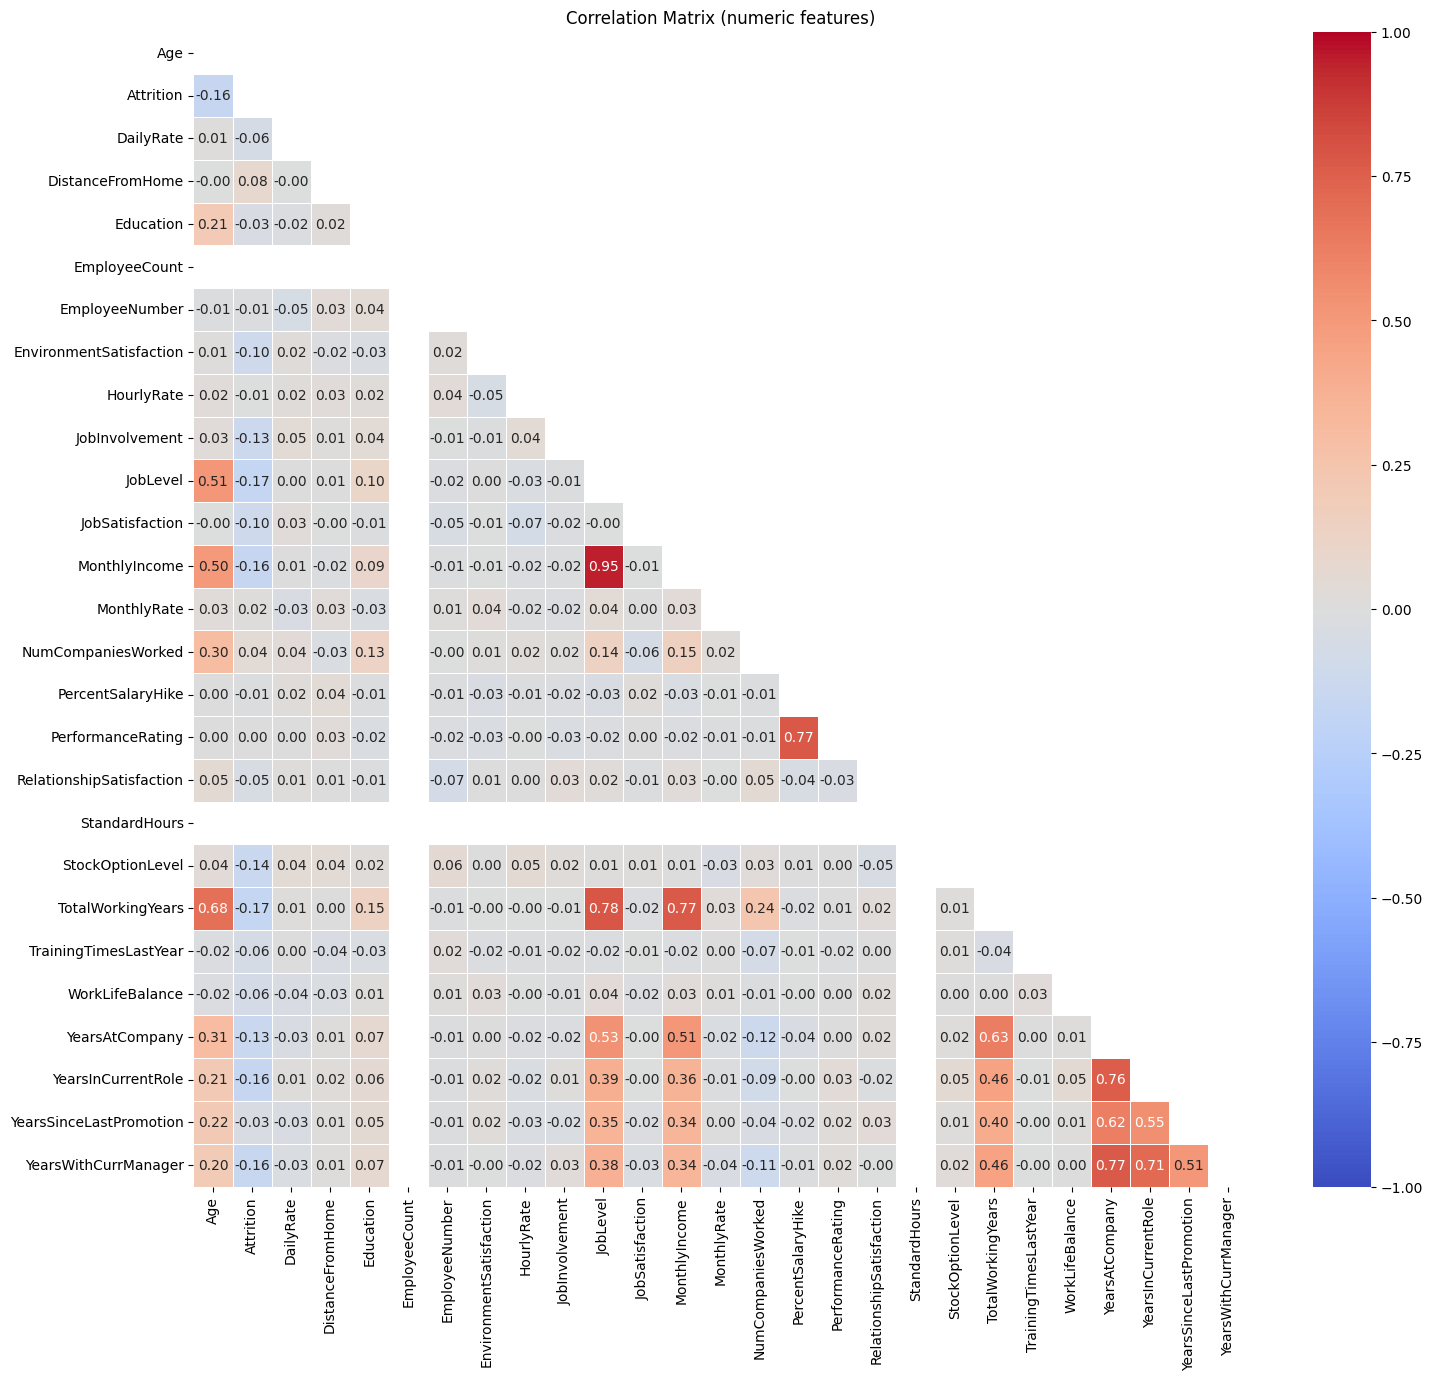

In [ ]:
#Correlation Matrix for numeric features
%pip install seaborn
%pip install numpy
import seaborn as sns
import numpy as np

# convert Attrition to numeric and compute correlations for numeric columns
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
num_cols = df_corr.select_dtypes(include='number').columns
corr = df_corr[num_cols].corr()

# plot heatmap (mask upper triangle)
plt.figure(figsize=(17, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix (numeric features)")
plt.show()

# Correlated variables to be removed
1. Keep MonthlyIncome and drop JobLevel 
2. YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion. These four are strongly correlated because they all measure tenure in different ways. Keep YearsAtCompany and YearsSinceLastPromotion (most predictive for attrition). Remove YearsInCurrentRole, YearsWithCurrManager.
3. In this dataset, PerformanceRating is almost always 3 or 4, and it is directly tied to salary hike policy. Drop PerformanceRating (low variance + redundant).
4. Variables That Are Categorical Mirrors of Each Other. For example JobRole is nested inside Department (Sales → Sales Executive, Sales Rep). Keep JobRole (more granular) and Drop Department.

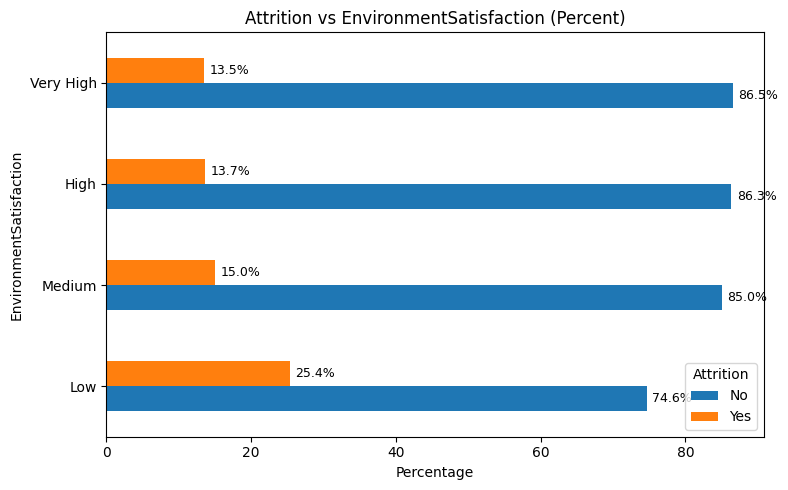

In [3]:
# Attrition vs EnvironmentSatisfaction: percentage bar chart


import matplotlib.pyplot as plt


env_labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ct_env_pct = (
    pd.crosstab(df['EnvironmentSatisfaction'], df['Attrition'], normalize='index')
      .sort_index()
      .mul(100)
)

ct_env_pct.index = ct_env_pct.index.map(env_labels)

ax_env_pct = ct_env_pct.plot(kind='barh', figsize=(8, 5))

for p in ax_env_pct.patches:
    w = p.get_width()
    if w > 0:
        ax_env_pct.annotate(
            f'{w:.1f}%',
            (w, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            fontsize=9,
            xytext=(4, 0),
            textcoords='offset points'
        )

ax_env_pct.set_xlabel('Percentage')
ax_env_pct.set_ylabel('EnvironmentSatisfaction')
ax_env_pct.set_title('Attrition vs EnvironmentSatisfaction (Percent)')
ax_env_pct.legend(title='Attrition')
plt.tight_layout()
plt.show()

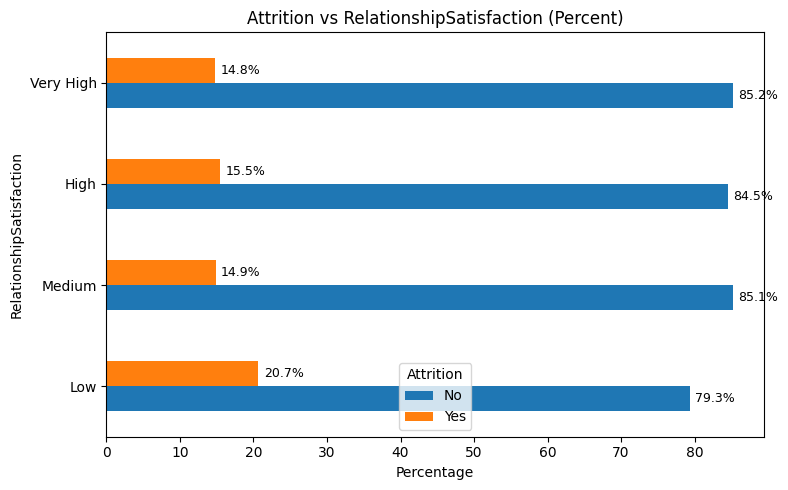

In [4]:
# Attrition vs RelationshipSatisfaction: percentage bar chart
rel_labels = {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
}

ct_rel_pct = (
    pd.crosstab(df['RelationshipSatisfaction'], df['Attrition'], normalize='index')
      .sort_index()
      .mul(100)
)

ct_rel_pct.index = ct_rel_pct.index.map(rel_labels)

ax_rel_pct = ct_rel_pct.plot(kind='barh', figsize=(8, 5))

for p in ax_rel_pct.patches:
    w = p.get_width()
    if w > 0:
        ax_rel_pct.annotate(
            f'{w:.1f}%',
            (w, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            fontsize=9,
            xytext=(4, 0),
            textcoords='offset points'
        )

ax_rel_pct.set_xlabel('Percentage')
ax_rel_pct.set_ylabel('RelationshipSatisfaction')
ax_rel_pct.set_title('Attrition vs RelationshipSatisfaction (Percent)')
ax_rel_pct.legend(title='Attrition')
plt.tight_layout()
plt.show()

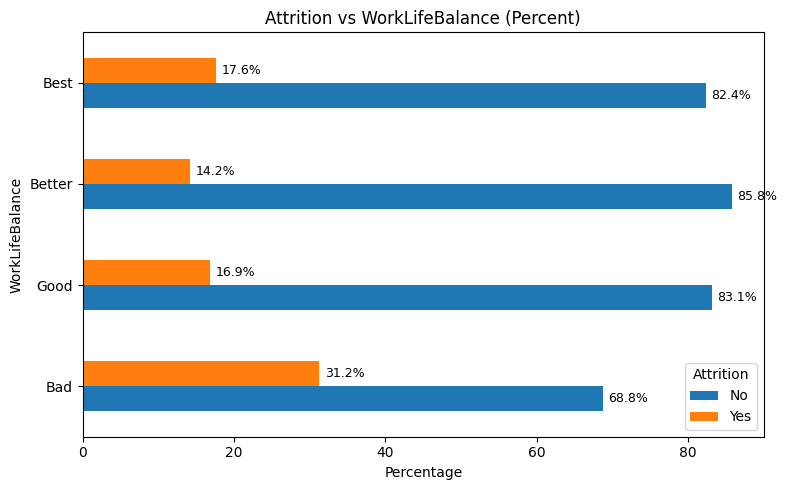

In [5]:
# Attrition vs WorkLifeBalance: percentage bar chart
wlb_labels = {
    1: 'Bad',
    2: 'Good',
    3: 'Better',
    4: 'Best'
}

ct_wlb_pct = (
    pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index')
      .sort_index()
      .mul(100)
)

ct_wlb_pct.index = ct_wlb_pct.index.map(wlb_labels)

ax_wlb_pct = ct_wlb_pct.plot(kind='barh', figsize=(8, 5))

for p in ax_wlb_pct.patches:
    w = p.get_width()
    if w > 0:
        ax_wlb_pct.annotate(
            f'{w:.1f}%',
            (w, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            fontsize=9,
            xytext=(4, 0),
            textcoords='offset points'
        )

ax_wlb_pct.set_xlabel('Percentage')
ax_wlb_pct.set_ylabel('WorkLifeBalance')
ax_wlb_pct.set_title('Attrition vs WorkLifeBalance (Percent)')
ax_wlb_pct.legend(title='Attrition')
plt.tight_layout()
plt.show()

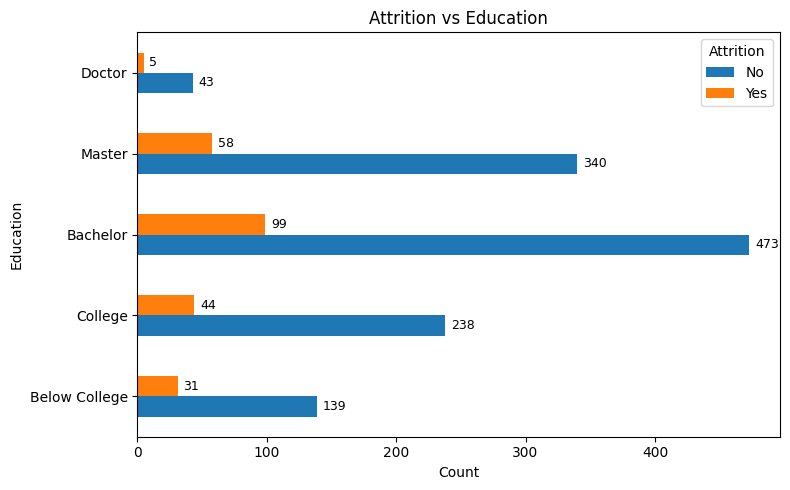

In [10]:
# Attrition vs Education: labeled horizontal bar chart
edu_labels = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

ct_education = pd.crosstab(df['Education'], df['Attrition']).sort_index()
ct_education.index = ct_education.index.map(edu_labels)

ax_education = ct_education.plot(kind='barh', figsize=(8, 5))

for p in ax_education.patches:
    w = p.get_width()
    if w > 0:
        ax_education.annotate(
            f'{int(w)}',
            (w, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            fontsize=9,
            xytext=(4, 0),
            textcoords='offset points'
        )

ax_education.set_xlabel('Count')
ax_education.set_ylabel('Education')
ax_education.set_title('Attrition vs Education')
ax_education.legend(title='Attrition')
plt.tight_layout()
plt.show()

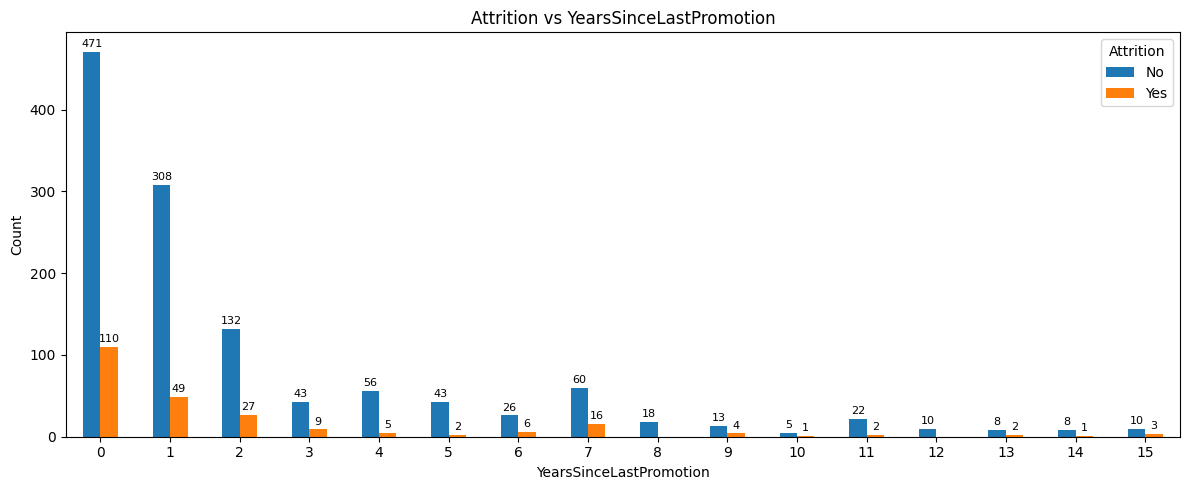

In [9]:
# Attrition vs YearsSinceLastPromotion: labeled bar chart
ct_yslp = pd.crosstab(df['YearsSinceLastPromotion'], df['Attrition']).sort_index()

ax_yslp = ct_yslp.plot(kind='bar', figsize=(12, 5), rot=0)

for p in ax_yslp.patches:
    h = p.get_height()
    if h > 0:
        ax_yslp.annotate(
            f'{int(h)}',
            (p.get_x() + p.get_width() / 2, h),
            ha='center',
            va='bottom',
            fontsize=8,
            xytext=(0, 2),
            textcoords='offset points'
        )

ax_yslp.set_xlabel('YearsSinceLastPromotion')
ax_yslp.set_ylabel('Count')
ax_yslp.set_title('Attrition vs YearsSinceLastPromotion')
ax_yslp.legend(title='Attrition')
plt.tight_layout()
plt.show()

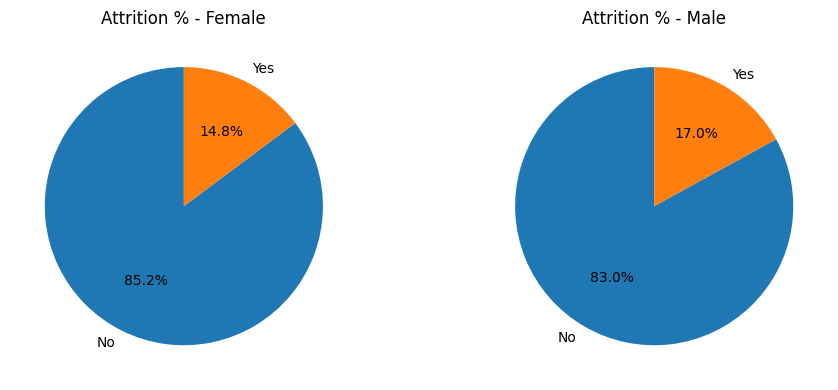

In [6]:
# Attrition by Gender: pie charts (percentage) for each gender
gender_attr_pct = pd.crosstab(df['Gender'], df['Attrition'], normalize='index') * 100

fig, axes = plt.subplots(1, len(gender_attr_pct), figsize=(10, 4))

if len(gender_attr_pct) == 1:
    axes = [axes]

for ax, (gender, row) in zip(axes, gender_attr_pct.iterrows()):
    ax.pie(row.values, labels=row.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Attrition % - {gender}')

plt.tight_layout()
plt.show()

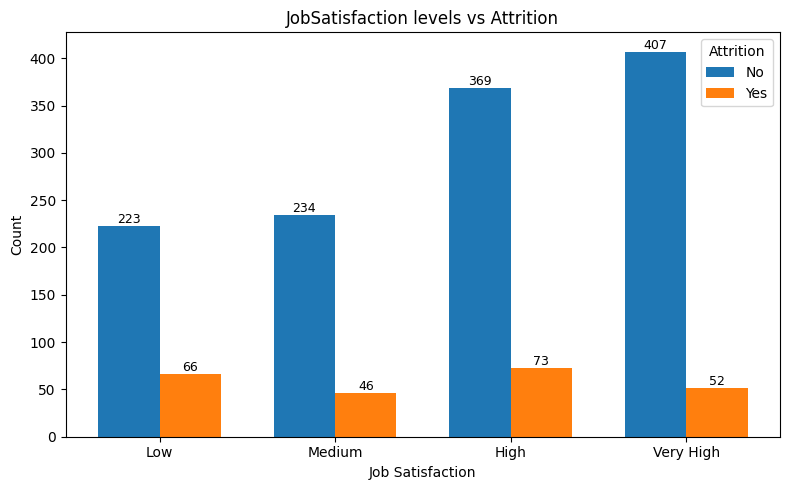

In [16]:
# Clustered bar chart: JobSatisfaction levels vs attrition with labels
fig3, ax5 = plt.subplots(figsize=(8,5))
labels = ['Low', 'Medium', 'High', 'Very High']
x = range(len(labels))
width = 0.35

no_counts = js_ct['No'].values
yes_counts = js_ct['Yes'].values

bars_no = ax5.bar([i - width/2 for i in x], no_counts, width, label='No')
bars_yes = ax5.bar([i + width/2 for i in x], yes_counts, width, label='Yes')

for bar in list(bars_no) + list(bars_yes):
    ax5.annotate(f'{int(bar.get_height())}',
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', fontsize=9)

ax5.set_xlabel('Job Satisfaction')
ax5.set_ylabel('Count')
ax5.set_title('JobSatisfaction levels vs Attrition')
ax5.set_xticks(list(x))
ax5.set_xticklabels(labels)
ax5.legend(title='Attrition')
plt.tight_layout()
plt.show()

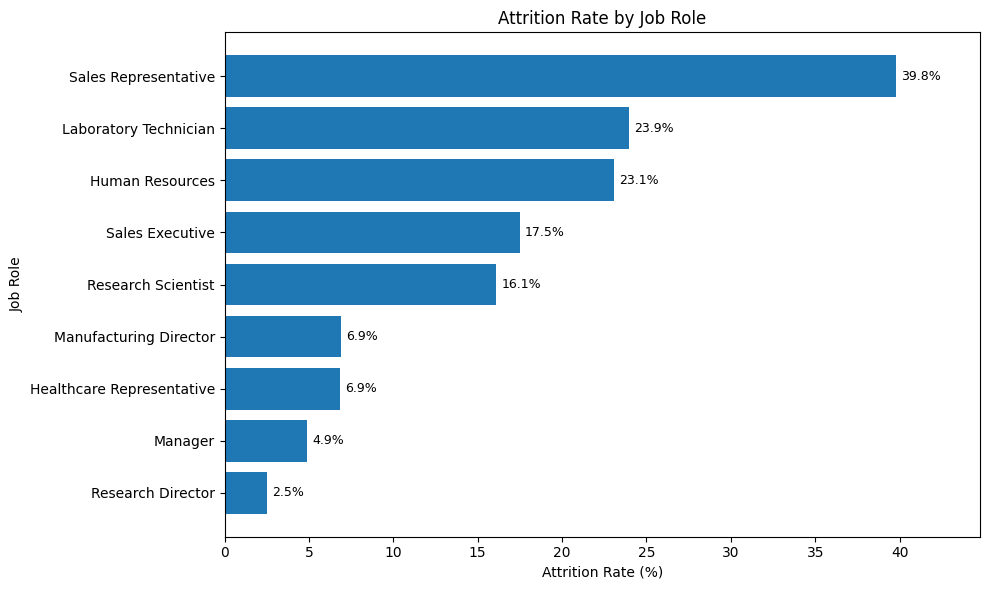

In [6]:
# Attrition rate by JobRole (labeled horizontal bar chart)
attrition_rate_by_job = (
    df.assign(AttritionFlag=df["Attrition"].eq("Yes"))
      .groupby("JobRole")["AttritionFlag"]
      .mean()
      .sort_values()
      * 100
)

fig_job, ax_job = plt.subplots(figsize=(10, 6))
bars = ax_job.barh(attrition_rate_by_job.index, attrition_rate_by_job.values, color="tab:blue")

for bar, val in zip(bars, attrition_rate_by_job.values):
    ax_job.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)

ax_job.set_xlabel("Attrition Rate (%)")
ax_job.set_ylabel("Job Role")
ax_job.set_title("Attrition Rate by Job Role")
ax_job.set_xlim(0, attrition_rate_by_job.max() + 5)
plt.tight_layout()
plt.show()

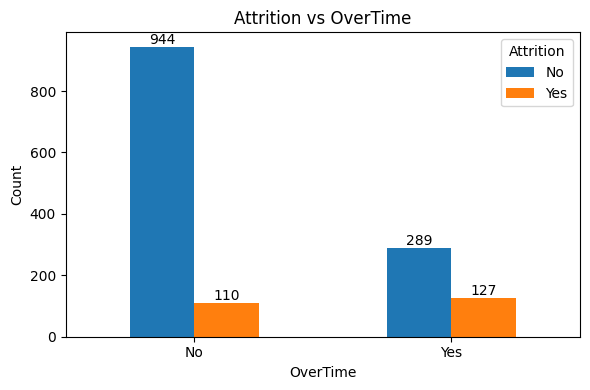

In [6]:
# Show Attrition vs Overtime Grouped Bar Chart
import matplotlib.pyplot as plt

ax = ct.plot(kind='bar', rot=0, figsize=(6,4))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
ax.set_xlabel('OverTime')
ax.set_ylabel('Count')
ax.set_title('Attrition vs OverTime')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

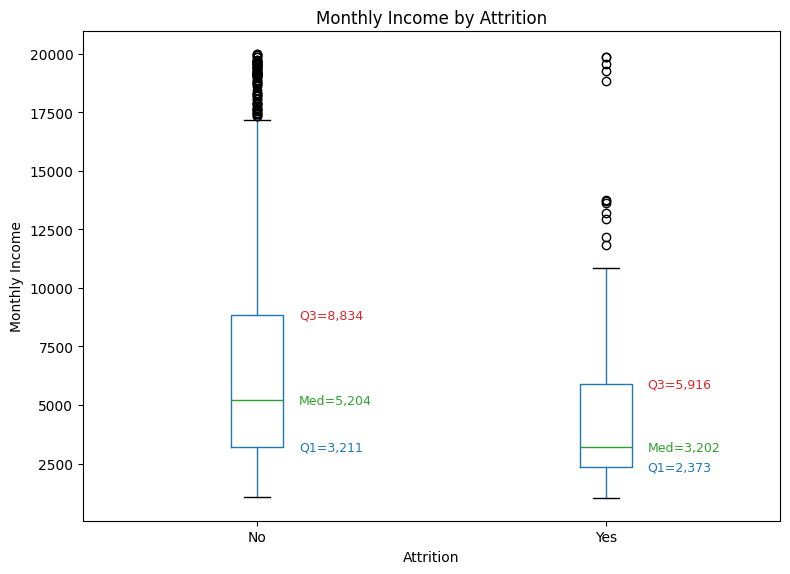

In [21]:
# Boxplot: MonthlyIncome vs Attrition with quartile labels
fig_mi, ax_mi = plt.subplots(figsize=(8,6))
df.boxplot(column='MonthlyIncome', by='Attrition', ax=ax_mi, grid=False)
ax_mi.set_title('Monthly Income by Attrition')
plt.suptitle('')
ax_mi.set_xlabel('Attrition')
ax_mi.set_ylabel('Monthly Income')

# compute quartiles
q_mi = df.groupby('Attrition')['MonthlyIncome'].quantile([0.25, 0.5, 0.75]).unstack()

# annotate quartiles next to each box
xticks = ax_mi.get_xticks()
for i, group in enumerate(q_mi.index):
    pos = xticks[i]
    q1, med, q3 = q_mi.loc[group, 0.25], q_mi.loc[group, 0.5], q_mi.loc[group, 0.75]
    ax_mi.text(pos + 0.12, q1,  f'Q1={int(q1):,}', fontsize=9, va='center', color='tab:blue')
    ax_mi.text(pos + 0.12, med, f'Med={int(med):,}', fontsize=9, va='center', color='tab:green')
    ax_mi.text(pos + 0.12, q3,  f'Q3={int(q3):,}', fontsize=9, va='center', color='tab:red')

plt.tight_layout()
plt.show()

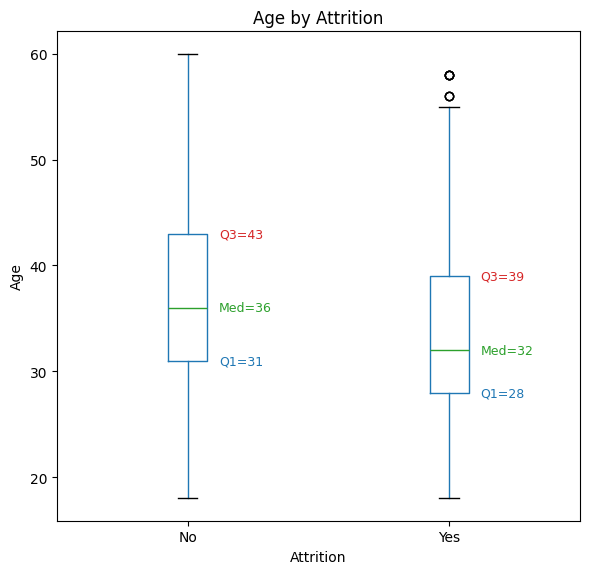

In [20]:
# Boxplot: Age vs Attrition with quartile labels
fig, ax_age = plt.subplots(figsize=(6,6))
df.boxplot(column='Age', by='Attrition', ax=ax_age, grid=False)
ax_age.set_title('Age by Attrition')
plt.suptitle('')
ax_age.set_xlabel('Attrition')
ax_age.set_ylabel('Age')

# compute quartiles
q = df.groupby('Attrition')['Age'].quantile([0.25, 0.5, 0.75]).unstack()

# annotate quartiles next to each box
xticks = ax_age.get_xticks()
for i, group in enumerate(q.index):
    pos = xticks[i]
    q1, med, q3 = q.loc[group, 0.25], q.loc[group, 0.5], q.loc[group, 0.75]
    ax_age.text(pos + 0.12, q1,  f'Q1={int(q1)}', fontsize=9, va='center', color='tab:blue')
    ax_age.text(pos + 0.12, med, f'Med={int(med)}', fontsize=9, va='center', color='tab:green')
    ax_age.text(pos + 0.12, q3,  f'Q3={int(q3)}', fontsize=9, va='center', color='tab:red')

plt.tight_layout()
plt.show()

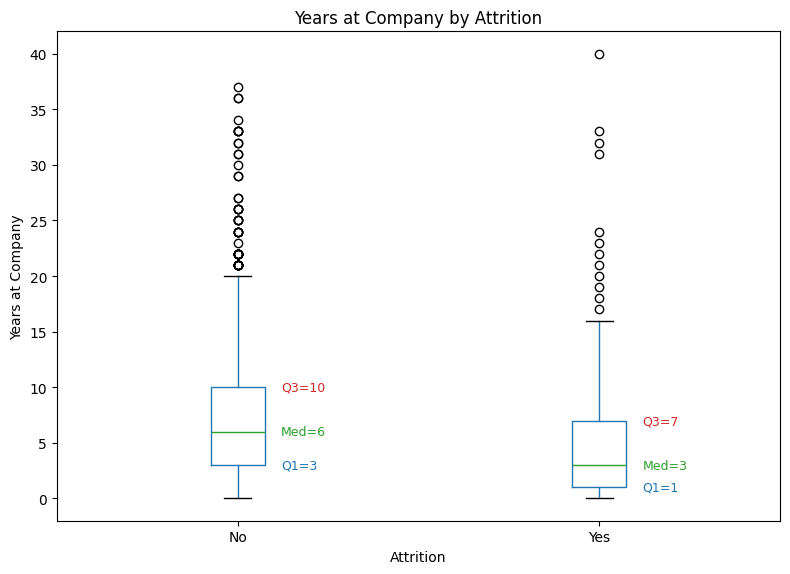

In [5]:
# Boxplot: YearsAtCompany vs Attrition with quartile labels
fig_yac, ax_yac = plt.subplots(figsize=(8, 6))
df.boxplot(column='YearsAtCompany', by='Attrition', ax=ax_yac, grid=False)
ax_yac.set_title('Years at Company by Attrition')
plt.suptitle('')
ax_yac.set_xlabel('Attrition')
ax_yac.set_ylabel('Years at Company')

# compute quartiles
q_yac = df.groupby('Attrition')['YearsAtCompany'].quantile([0.25, 0.5, 0.75]).unstack()

# annotate quartiles next to each box
xticks = ax_yac.get_xticks()
for i, group in enumerate(q_yac.index):
    pos = xticks[i]
    q1, med, q3 = q_yac.loc[group, 0.25], q_yac.loc[group, 0.5], q_yac.loc[group, 0.75]
    ax_yac.text(pos + 0.12, q1,  f'Q1={int(q1)}', fontsize=9, va='center', color='tab:blue')
    ax_yac.text(pos + 0.12, med, f'Med={int(med)}', fontsize=9, va='center', color='tab:green')
    ax_yac.text(pos + 0.12, q3,  f'Q3={int(q3)}', fontsize=9, va='center', color='tab:red')

plt.tight_layout()
plt.show()